In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
# 1) Carregar dataset e montar DataFrame
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["target_name"] = [target_names[i] for i in y]

print("Wine — DataFrame com nomes de colunas")
print(df)

Wine — DataFrame com nomes de colunas
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoi

In [3]:
# 2) scatter_3d: escolher alcohol, malic_acid, proline 
fig = px.scatter_3d(df, x="alcohol", y="malic_acid", z="proline", color="target_name")
fig.show()


In [4]:
# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=13, stratify=y)

In [5]:
# 4) Treinar KNN n_neighbors=10
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_10.fit(X_train, y_train)
y_pred_10 = knn_10.predict(X_test)

== Classification Report (k=10) ==

              precision    recall  f1-score   support

     class_0       0.75      1.00      0.86        18
     class_1       0.80      0.76      0.78        21
     class_2       0.70      0.47      0.56        15

    accuracy                           0.76        54
   macro avg       0.75      0.74      0.73        54
weighted avg       0.76      0.76      0.74        54

== Confusion Matrix (k=10) ==



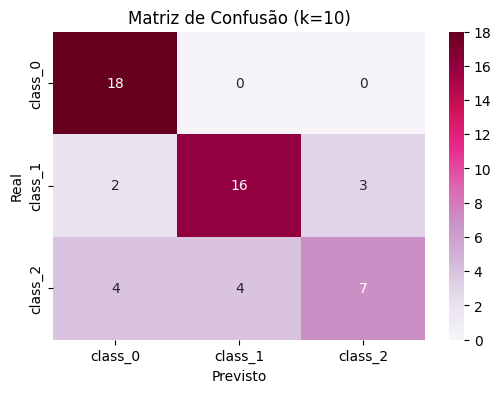

In [6]:
# 5) Avaliações
report_10 = classification_report(y_test, y_pred_10, target_names=target_names, output_dict=False)
cm_10 = confusion_matrix(y_test, y_pred_10)

print("== Classification Report (k=10) ==\n")
print(classification_report(y_test, y_pred_10, target_names=target_names))

print("== Confusion Matrix (k=10) ==\n")
cm = confusion_matrix(y_test, y_pred_10)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", xticklabels=target_names, yticklabels=target_names)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão (k=10)")
plt.show()

In [7]:
# 6) Outros 4 valores de k e comparação
ks = [10, 9, 5, 15, 25]
rows = []
all_reports = {}

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    rows.append({"k": k, "accuracy": acc, "f1_macro": f1_macro})
    all_reports[k] = {
        "classification_report": classification_report(
            y_test, y_pred, target_names=target_names
        ),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

metrics_df = pd.DataFrame(rows).sort_values(by=["accuracy", "f1_macro", "k"], ascending=[False, False, True]).reset_index(drop=True)
print("Wine — Comparação de ks (accuracy e f1_macro)")
print(metrics_df)


best_row = metrics_df.iloc[0]
best_k = int(best_row["k"])
best_acc = float(best_row["accuracy"])
best_f1 = float(best_row["f1_macro"])

print(f"""\n\nForam testados os valores de k = {ks}.
A comparação mostra que o melhor desempenho foi obtido com:

    k = {best_k}
    accuracy = {best_acc:.5f}
    f1_macro = {best_f1:.5f}

Portanto, a melhor configuração de hiperparâmetros para o KNN neste problema foi k = {best_k}, que apresentou o equilíbrio ideal entre acurácia e f1_macro.""")

Wine — Comparação de ks (accuracy e f1_macro)
    k  accuracy  f1_macro
0   9  0.759259  0.739655
1  10  0.759259  0.732544
2  25  0.722222  0.705848
3  15  0.703704  0.685714
4   5  0.666667  0.630586


Foram testados os valores de k = [10, 9, 5, 15, 25].
A comparação mostra que o melhor desempenho foi obtido com:

    k = 9
    accuracy = 0.75926
    f1_macro = 0.73966

Portanto, a melhor configuração de hiperparâmetros para o KNN neste problema foi k = 9, que apresentou o equilíbrio ideal entre acurácia e f1_macro.


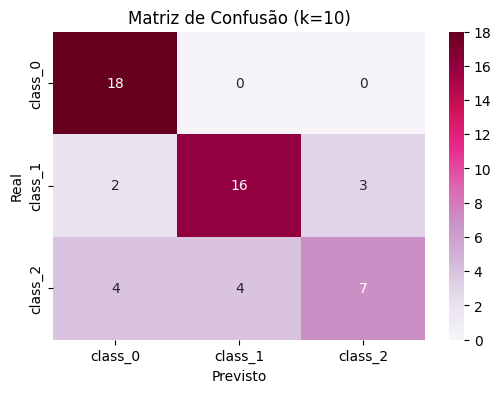

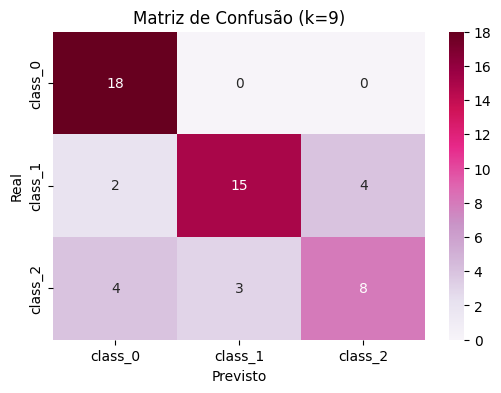

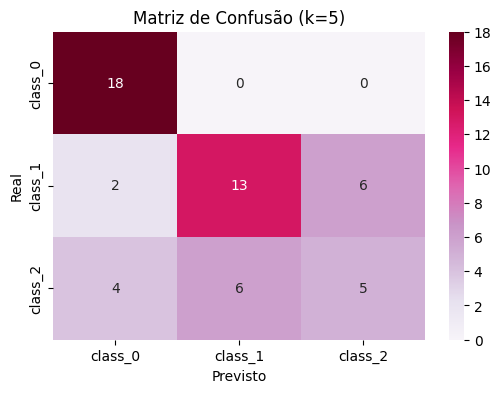

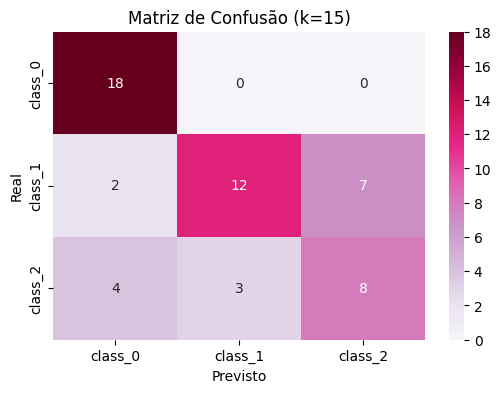

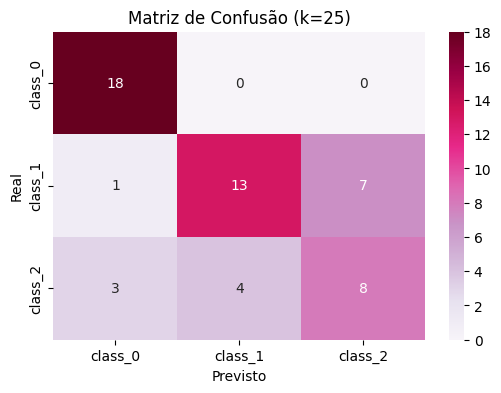

In [8]:
for key, value in all_reports.items():
    plt.figure(figsize=(6,4))
    sns.heatmap(value['confusion_matrix'], annot=True, fmt="d", cmap="PuRd", xticklabels=target_names, yticklabels=target_names)

    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusão (k={key})")
    plt.show()